In [199]:
import pandas as pd
import glob
import os

In [200]:
# Ruta a la carpeta con los CSVs
CARPETA = os.path.join(os.getcwd(), "..", "Data_Raw", "Casas")

# Leer y apilar todos los CSVs
archivos = glob.glob(os.path.join(CARPETA, "*.csv"))

# Comprobar si todas las columnas son iguales
columnas = [pd.read_csv(f).columns.tolist() for f in archivos]

todas_iguales = all(c == columnas[0] for c in columnas)

if todas_iguales:
    print("Todas las columnas son iguales")
else:
    print("Hay diferencias en las columnas:")
    for f, cols in zip(archivos, columnas):
        print(f"\n  {os.path.basename(f)}:")
        print(f"  {cols}")

Todas las columnas son iguales


In [201]:
# Ruta a la carpeta con los CSVs
CARPETA = os.path.join(os.getcwd(), "..", "Data_Raw", "Casas")

# Leer y apilar todos los CSVs
archivos = glob.glob(os.path.join(CARPETA, "*.csv"))

print(f"Archivos encontrados: {len(archivos)}")
for f in archivos:
    print(f"  - {os.path.basename(f)}")

df_casas = pd.concat(
    [pd.read_csv(f) for f in archivos],
    ignore_index=True
)

Archivos encontrados: 20
  - houses_alava.csv
  - houses_albacete.csv
  - houses_alicante.csv
  - houses_balears.csv
  - houses_barcelona.csv
  - houses_bizkaia.csv
  - houses_cadiz.csv
  - houses_ciudad_real.csv
  - houses_coruna.csv
  - houses_gipuzkoa.csv
  - houses_girona.csv
  - houses_huelva.csv
  - houses_madrid.csv
  - houses_santa_cruz_de_tenerife.csv
  - houses_segovia.csv
  - houses_sevilla.csv
  - houses_soria.csv
  - houses_valencia.csv
  - houses_valladolid.csv
  - houses_zamora.csv


In [202]:
print(f"\nDataframe creado: {df_casas.shape[0]} filas x {df_casas.shape[1]} columnas")


Dataframe creado: 100000 filas x 36 columnas


In [203]:
df_casas.head()


,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,m2_useful,obtention_date,orientation,price,reduced_mobility,room_num,storage_room,swimming_pool,terrace,unfurnished
0,Precio chalet individual en la localidad de Ab...,Anuncio actualizado el 27 de marzo,0,0,2,0,0,segunda mano/buen estado,NaN,NaN,...,172.0,2019-03-29,"norte, sur, este, oeste",310000,0,4,0,0,1,NaN
1,"Atico de 80m2, para entrar a vivir, con salón ...",más de 5 meses sin actualizar,0,0,2,0,0,segunda mano/buen estado,2006.0,no indicado,...,NaN,2019-03-29,NaN,139000,1,3,1,0,0,NaN
2,B/ Etxaguen. Casa de reciente construcción con...,más de 5 meses sin actualizar,0,0,3,0,0,segunda mano/buen estado,NaN,no indicado,...,NaN,2019-03-29,NaN,480000,0,4,1,0,1,NaN
3,Se vende vivienda en abornikano (ayuntamiento ...,más de 5 meses sin actualizar,0,1,1,1,1,segunda mano/buen estado,NaN,en trámite,...,NaN,2019-03-29,NaN,150000,0,4,1,0,1,NaN
4,Negociables.,más de 5 meses sin actualizar,0,0,1,0,0,segunda mano/buen estado,NaN,no indicado,...,74.0,2019-03-29,"sur, oeste",90000,0,2,1,1,1,NaN


In [204]:
df_casas.info() #Al anexar muchos .csv se importan todos los datos como objetos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ad_description     95426 non-null   object
 1   ad_last_update     100000 non-null  object
 2   air_conditioner    100000 non-null  object
 3   balcony            100000 non-null  object
 4   bath_num           100000 non-null  object
 5   built_in_wardrobe  100000 non-null  object
 6   chimney            100000 non-null  object
 7   condition          86059 non-null   object
 8   construct_date     32059 non-null   object
 9   energetic_certif   74691 non-null   object
 10  floor              79693 non-null   object
 11  garage             40811 non-null   object
 12  garden             100000 non-null  object
 13  ground_size        183 non-null     object
 14  heating            25714 non-null   object
 15  house_id           100000 non-null  object
 16  house_type         10

In [205]:
#Cambiamos tipos
df_casas['price']      = pd.to_numeric(df_casas['price'], errors='coerce')
df_casas['m2_real']    = pd.to_numeric(df_casas['m2_real'], errors='coerce')
df_casas['m2_useful']  = pd.to_numeric(df_casas['m2_useful'], errors='coerce')
df_casas['ground_size']= pd.to_numeric(df_casas['ground_size'], errors='coerce')
df_casas["room_num"] = pd.to_numeric(df_casas["room_num"], errors="coerce").astype("Int64")
df_casas["bath_num"] = pd.to_numeric(df_casas["bath_num"], errors="coerce").astype("Int64")
df_casas['floor']      = pd.to_numeric(df_casas['floor'], errors='coerce')

In [206]:
#Cambiamos tipos
df_casas['obtention_date']  = pd.to_datetime(df_casas['obtention_date'], errors='coerce')
df_casas['construct_date']  = pd.to_datetime(df_casas['construct_date'], errors='coerce')

In [207]:
#Cambiamos tipos
bool_cols = ['air_conditioner', 'balcony', 'built_in_wardrobe', 'chimney',
             'garage', 'garden', 'heating', 'lift', 'reduced_mobility',
             'storage_room', 'swimming_pool', 'terrace', 'kitchen', 'unfurnished']

for col in bool_cols:
    df_casas[col] = df_casas[col].map({'True': True, 'False': False, 'yes': True, 'no': False})

In [208]:
df_casas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ad_description     95426 non-null   object        
 1   ad_last_update     100000 non-null  object        
 2   air_conditioner    0 non-null       object        
 3   balcony            0 non-null       object        
 4   bath_num           99147 non-null   Int64         
 5   built_in_wardrobe  0 non-null       object        
 6   chimney            0 non-null       object        
 7   condition          86059 non-null   object        
 8   construct_date     31873 non-null   datetime64[ns]
 9   energetic_certif   74691 non-null   object        
 10  floor              0 non-null       float64       
 11  garage             0 non-null       object        
 12  garden             0 non-null       object        
 13  ground_size        0 non-null       float64  

In [209]:
#Vemos el porcentaje de valores nulos por columna, y los ordenamos de mayor a menor
nulos = (df_casas.isnull().sum() / len(df_casas) * 100).sort_values(ascending=False)
print(nulos.round(2))

lift                 100.00
garage               100.00
terrace              100.00
swimming_pool        100.00
storage_room         100.00
reduced_mobility     100.00
kitchen              100.00
heating              100.00
ground_size          100.00
garden               100.00
unfurnished          100.00
floor                100.00
chimney              100.00
air_conditioner      100.00
balcony              100.00
built_in_wardrobe    100.00
loc_street            85.69
construct_date        68.13
orientation           60.58
loc_neigh             56.31
m2_useful             47.34
energetic_certif      25.31
condition             13.94
loc_district          13.75
ad_description         4.57
room_num               1.44
bath_num               0.85
m2_real                0.18
obtention_date         0.18
price                  0.18
ad_last_update         0.00
loc_zone               0.00
house_id               0.00
loc_full               0.00
loc_city               0.00
house_type          

In [210]:
cols_100_nulos = nulos[nulos == 100].index #Eliminamos las columnas que tienen el 100% de valores nulos
df_casas = df_casas.drop(columns=cols_100_nulos)

print(f"Columnas eliminadas: {len(cols_100_nulos)}")
print(f"Columnas restantes: {df_casas.shape[1]}")

Columnas eliminadas: 16
Columnas restantes: 20


In [211]:
df_casas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ad_description    95426 non-null   object        
 1   ad_last_update    100000 non-null  object        
 2   bath_num          99147 non-null   Int64         
 3   condition         86059 non-null   object        
 4   construct_date    31873 non-null   datetime64[ns]
 5   energetic_certif  74691 non-null   object        
 6   house_id          100000 non-null  object        
 7   house_type        100000 non-null  object        
 8   loc_city          100000 non-null  object        
 9   loc_district      86253 non-null   object        
 10  loc_full          100000 non-null  object        
 11  loc_neigh         43690 non-null   object        
 12  loc_street        14314 non-null   object        
 13  loc_zone          100000 non-null  object        
 14  m2_re

In [212]:
# Estado actual del dataframe
print(df_casas.shape)
print(df_casas.dtypes)
print("\nNulos por columna:")
print((df_casas.isnull().sum() / len(df_casas) * 100).sort_values(ascending=False).round(2))

(100000, 20)
ad_description              object
ad_last_update              object
bath_num                     Int64
condition                   object
construct_date      datetime64[ns]
energetic_certif            object
house_id                    object
house_type                  object
loc_city                    object
loc_district                object
loc_full                    object
loc_neigh                   object
loc_street                  object
loc_zone                    object
m2_real                    float64
m2_useful                  float64
obtention_date      datetime64[ns]
orientation                 object
price                      float64
room_num                     Int64
dtype: object

Nulos por columna:
loc_street          85.69
construct_date      68.13
orientation         60.58
loc_neigh           56.31
m2_useful           47.34
energetic_certif    25.31
condition           13.94
loc_district        13.75
ad_description       4.57
room_num           

In [213]:
# Eliminamos columnas que no dan informción relevante para el análisis, o que tienen demasiados valores nulos
df_casas = df_casas.drop(columns=["loc_street", "loc_neigh", "ad_description"])

# Condition y loc_district lo rellenar con "Desconocido"
df_casas["condition"]    = df_casas["condition"].fillna("Desconocido")
df_casas["loc_district"] = df_casas["loc_district"].fillna("Desconocido")

# Rellenar con "no indicado"
df_casas["energetic_certif"] = df_casas["energetic_certif"].fillna("no indicado")



In [214]:
df_casas.head()

,ad_last_update,bath_num,condition,construct_date,energetic_certif,house_id,house_type,loc_city,loc_district,loc_full,loc_zone,m2_real,m2_useful,obtention_date,orientation,price,room_num
0,Anuncio actualizado el 27 de marzo,2,segunda mano/buen estado,NaT,no indicado,81717634,Casa o chalet independiente,Urcabustaiz,La iglesia,"La iglesia , Urcabustaiz , Zuya, Álava","Zuya, Álava",1000.0,172.0,2019-03-29,"norte, sur, este, oeste",310000.0,4
1,más de 5 meses sin actualizar,2,segunda mano/buen estado,1970-01-01 00:00:00.000002006,no indicado,29588074,Ático,Legutiano,"la Union Plazatxoa, 8","la Union Plazatxoa, 8 , Legutiano , Zuya, Álava","Zuya, Álava",86.0,NaN,2019-03-29,NaN,139000.0,3
2,más de 5 meses sin actualizar,3,segunda mano/buen estado,NaT,no indicado,37453116,Casa de pueblo,Aramaio,Calle Etxaguen s/n,"Calle Etxaguen s/n , Aramaio , Zuya, Álava","Zuya, Álava",3000.0,NaN,2019-03-29,NaN,480000.0,4
3,más de 5 meses sin actualizar,1,segunda mano/buen estado,NaT,en trámite,82568918,Casa de pueblo,Urcabustaiz,"CP 01449, 1449 CP","CP 01449, 1449 CP , Urcabustaiz , Zuya, Álava","Zuya, Álava",86.0,NaN,2019-03-29,NaN,150000.0,4
4,más de 5 meses sin actualizar,1,segunda mano/buen estado,NaT,no indicado,29135242,Piso,Urcabustaiz,"Calle Nueva Plaza, 9","Calle Nueva Plaza, 9 , Urcabustaiz , Zuya, Ál...","Zuya, Álava",76.0,74.0,2019-03-29,"sur, oeste",90000.0,2


In [215]:
print(df_casas.shape)

(100000, 17)


In [216]:
print(f"Duplicados: {df_casas.duplicated().sum()}")
df_casas = df_casas.drop_duplicates()

Duplicados: 183


In [217]:
print(df_casas.shape)
df_casas.head()

(99817, 17)


,ad_last_update,bath_num,condition,construct_date,energetic_certif,house_id,house_type,loc_city,loc_district,loc_full,loc_zone,m2_real,m2_useful,obtention_date,orientation,price,room_num
0,Anuncio actualizado el 27 de marzo,2,segunda mano/buen estado,NaT,no indicado,81717634,Casa o chalet independiente,Urcabustaiz,La iglesia,"La iglesia , Urcabustaiz , Zuya, Álava","Zuya, Álava",1000.0,172.0,2019-03-29,"norte, sur, este, oeste",310000.0,4
1,más de 5 meses sin actualizar,2,segunda mano/buen estado,1970-01-01 00:00:00.000002006,no indicado,29588074,Ático,Legutiano,"la Union Plazatxoa, 8","la Union Plazatxoa, 8 , Legutiano , Zuya, Álava","Zuya, Álava",86.0,NaN,2019-03-29,NaN,139000.0,3
2,más de 5 meses sin actualizar,3,segunda mano/buen estado,NaT,no indicado,37453116,Casa de pueblo,Aramaio,Calle Etxaguen s/n,"Calle Etxaguen s/n , Aramaio , Zuya, Álava","Zuya, Álava",3000.0,NaN,2019-03-29,NaN,480000.0,4
3,más de 5 meses sin actualizar,1,segunda mano/buen estado,NaT,en trámite,82568918,Casa de pueblo,Urcabustaiz,"CP 01449, 1449 CP","CP 01449, 1449 CP , Urcabustaiz , Zuya, Álava","Zuya, Álava",86.0,NaN,2019-03-29,NaN,150000.0,4
4,más de 5 meses sin actualizar,1,segunda mano/buen estado,NaT,no indicado,29135242,Piso,Urcabustaiz,"Calle Nueva Plaza, 9","Calle Nueva Plaza, 9 , Urcabustaiz , Zuya, Ál...","Zuya, Álava",76.0,74.0,2019-03-29,"sur, oeste",90000.0,2


In [218]:
df_casas.dtypes

ad_last_update              object
bath_num                     Int64
condition                   object
construct_date      datetime64[ns]
energetic_certif            object
house_id                    object
house_type                  object
loc_city                    object
loc_district                object
loc_full                    object
loc_zone                    object
m2_real                    float64
m2_useful                  float64
obtention_date      datetime64[ns]
orientation                 object
price                      float64
room_num                     Int64
dtype: object

In [219]:
df_casas["house_id"] = df_casas["house_id"].astype(str)

In [220]:
# energetic_certif, condition, house_type, orientation lo cambio a category para ahorrar memoria
cols_cat = ["energetic_certif", "condition", "house_type", "orientation"]
for col in cols_cat:
    df_casas[col] = df_casas[col].astype("category")

In [221]:
df_casas.dtypes

ad_last_update              object
bath_num                     Int64
condition                 category
construct_date      datetime64[ns]
energetic_certif          category
house_id                    object
house_type                category
loc_city                    object
loc_district                object
loc_full                    object
loc_zone                    object
m2_real                    float64
m2_useful                  float64
obtention_date      datetime64[ns]
orientation               category
price                      float64
room_num                     Int64
dtype: object

## Histogramas

In [222]:
columnas_num = df_casas.select_dtypes(include=['float64', 'int64']).columns

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns

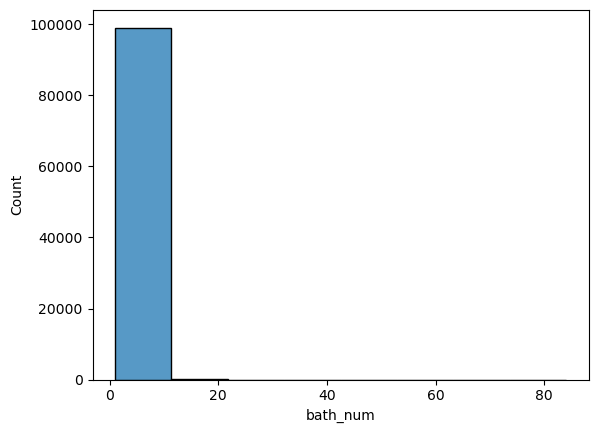

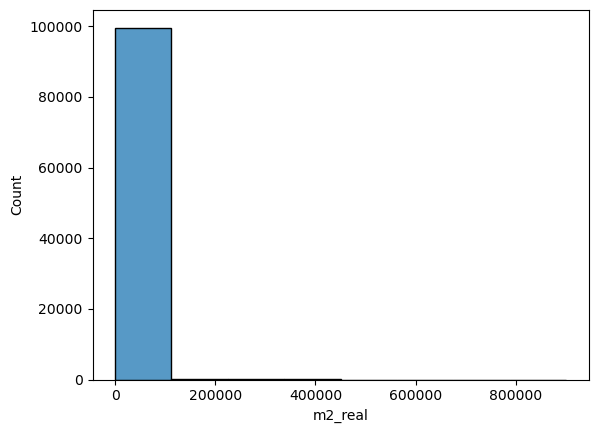

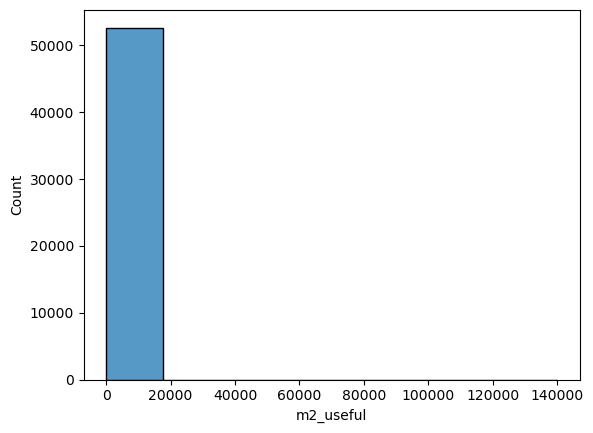

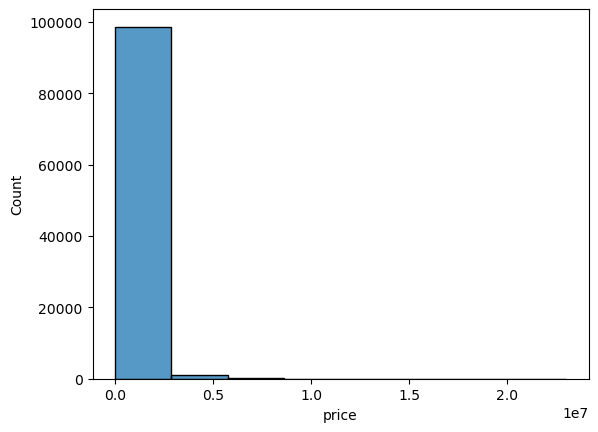

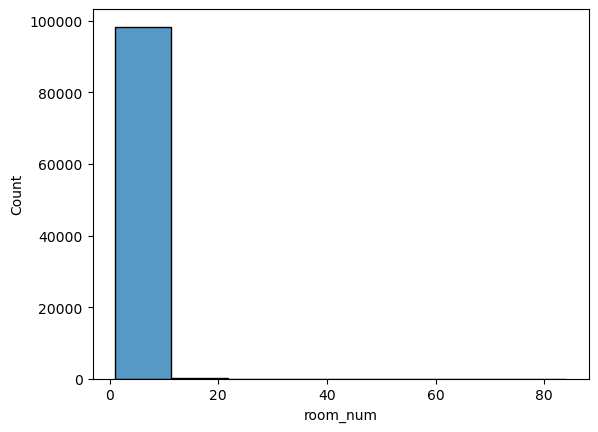

In [224]:
for col in columnas_num:
    
    plt.figure()
    sns.histplot(df_casas[col],bins=8)
    plt.show()

## Box Plot

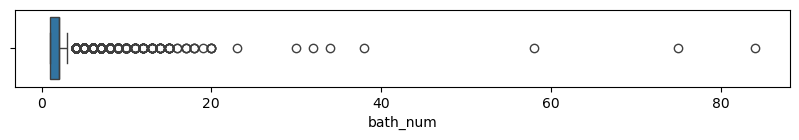

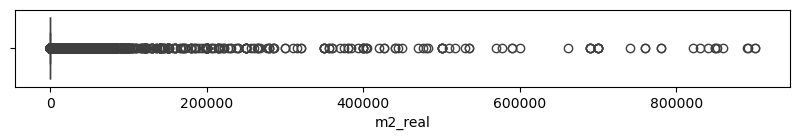

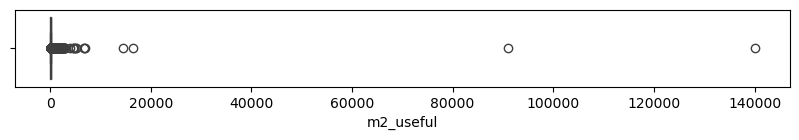

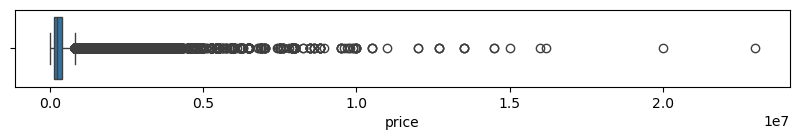

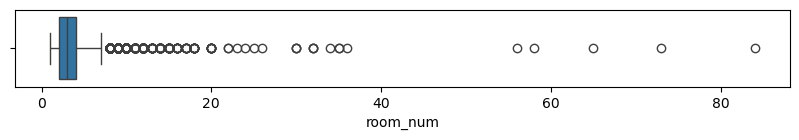

In [225]:
for col in columnas_num:
    
    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df_casas[col])
    plt.show()

In [226]:
# Hay bastantes outliers en las columnas numéricas

In [227]:
df_casas.columns

Index(['ad_last_update', 'bath_num', 'condition', 'construct_date',
       'energetic_certif', 'house_id', 'house_type', 'loc_city',
       'loc_district', 'loc_full', 'loc_zone', 'm2_real', 'm2_useful',
       'obtention_date', 'orientation', 'price', 'room_num'],
      dtype='object')

In [ ]:
df_casas['room_num']

count     98540.0
mean      3.23835
std      1.409062
min           1.0
25%           2.0
50%           3.0
75%           4.0
max          20.0
Name: room_num, dtype: Float64


In [237]:
df_casas["room_num"] = pd.to_numeric(df_casas["room_num"], errors="coerce")
df_casas["room_num"] = df_casas["room_num"].where(df_casas["room_num"] <= 20, other=pd.NA)

print(df_casas["room_num"].describe())

count     98540.0
mean      3.23835
std      1.409062
min           1.0
25%           2.0
50%           3.0
75%           4.0
max          20.0
Name: room_num, dtype: Float64


In [242]:
print(df_casas["room_num"].isnull().sum())

1276


In [243]:
# Hacemos lo mismo con bath_num, aunque no hay tantos outliers
df_casas["bath_num"] = pd.to_numeric(df_casas["bath_num"], errors="coerce")
df_casas["bath_num"] = df_casas["bath_num"].where(df_casas["bath_num"] <= 20, other=pd.NA)
print(df_casas["bath_num"].describe())

count     99138.0
mean     1.984406
std      1.137845
min           1.0
25%           1.0
50%           2.0
75%           2.0
max          20.0
Name: bath_num, dtype: Float64


In [244]:
print(df_casas["bath_num"].isnull().sum())

678


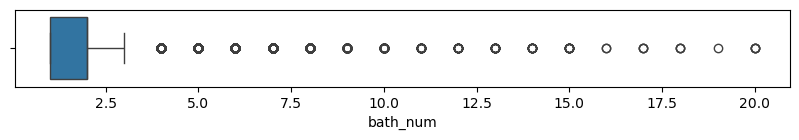

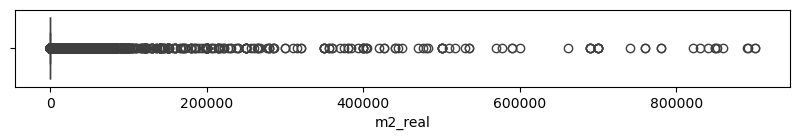

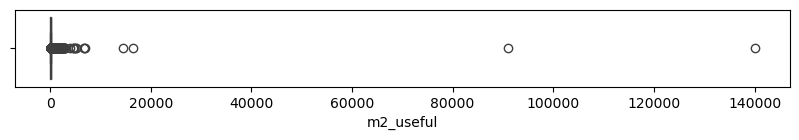

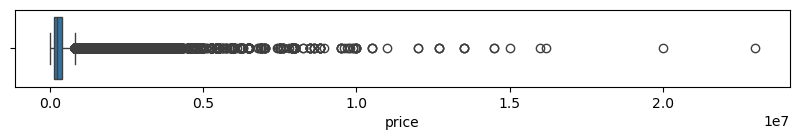

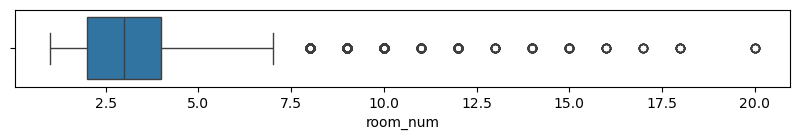

In [245]:
for col in columnas_num:
    
    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df_casas[col])
    plt.show()

In [246]:
# El resto de columnas las dejaremos igual por ahora, ya que puede ser información real

## Analisis columanas categóricas

In [230]:
df_casas.describe(include=['category', 'object']).T

,count,unique,top,freq
ad_last_update,99817,369,más de 5 meses sin actualizar,3208
condition,99817,5,segunda mano/buen estado,72271
energetic_certif,99817,4,no indicado,51067
house_id,99817,94524,40392886,2
house_type,99817,32,Piso,53963
loc_city,99817,1139,Palma de Mallorca,6538
loc_district,99817,23069,Desconocido,13747
loc_full,99817,49369,", Distrito Santa Ponça , Calvià , Mallorca, B...",555
loc_zone,99817,95,"Mallorca, Balears (Illes)",19649
orientation,39233,16,sur,13334


In [231]:
columnas_cat = df_casas.select_dtypes(include=['category', 'object']).columns

columnas_cat

Index(['ad_last_update', 'condition', 'energetic_certif', 'house_id',
       'house_type', 'loc_city', 'loc_district', 'loc_full', 'loc_zone',
       'orientation'],
      dtype='object')

In [232]:
for col in columnas_cat:

    print(f"La columna '{col}' tiene los siguientes valores únicos: {df_casas[col].nunique()}")
    print(df_casas[col].value_counts())

La columna 'ad_last_update' tiene los siguientes valores únicos: 369
ad_last_update
más de 5 meses sin actualizar           3208
Anuncio actualizado el 7 de abril       2725
Anuncio actualizado el 8 de abril       2725
Anuncio actualizado el 10 de abril      2379
Anuncio actualizado el 27 de marzo      2276
                                        ... 
Anuncio actualizado el 29 de julio         2
ad_last_update                             1
Anuncio actualizado el 19 de agosto        1
Anuncio actualizado el 29 de febrero       1
Anuncio actualizado el 24 de junio         1
Name: count, Length: 369, dtype: int64
La columna 'condition' tiene los siguientes valores únicos: 5
condition
segunda mano/buen estado      72271
Desconocido                   13941
segunda mano/para reformar    11045
promoción de obra nueva        2559
condition                         1
Name: count, dtype: int64
La columna 'energetic_certif' tiene los siguientes valores únicos: 4
energetic_certif
no indicado       

In [233]:
# Eliminamos filas que no dan inforación relevante para el análisis
df_casas = df_casas[df_casas["condition"] != "condition"]
df_casas["condition"] = df_casas["condition"].cat.remove_unused_categories()
df_casas = df_casas[df_casas["energetic_certif"] != "energetic_certif"]
df_casas["energetic_certif"] = df_casas["energetic_certif"].cat.remove_unused_categories()

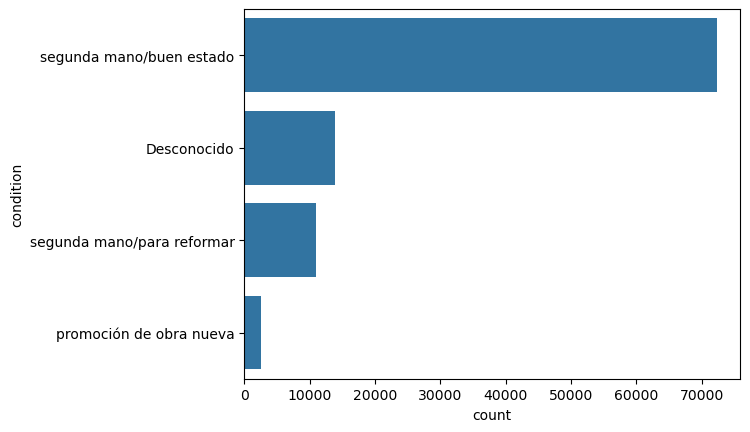

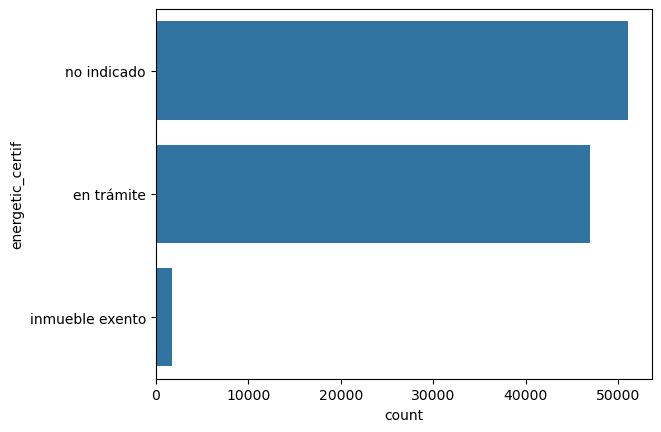

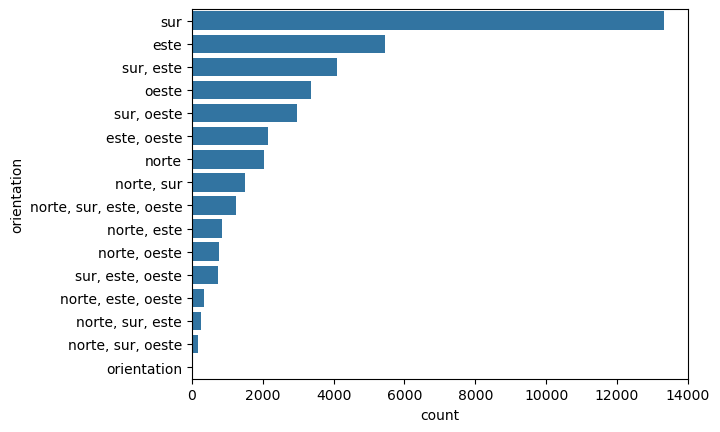

In [234]:
#Representamos lo anterior graficamente con countplot para las columnas categóricas
for col in columnas_cat:
    if df_casas[col].nunique() > 20: #Si hay más de 20 valores únicos, no lo representamos con countplot
        continue
    
    plt.figure()
    sns.countplot(df_casas[col], order=df_casas[col].value_counts().index) #Ordenamos las barras de mayor a menor
    plt.show()      

### La varible energetic_certif no aporta mucho valor, pero la mantendremmos